In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset
df = pd.read_excel("Integrated_Traffic_Dataset_Shalini.xlsx")

# View first rows
df.head()

,Date,Junction,Traffic_Volume,Temperature,Rain,Humidity,Event
0,2015-01-01 00:00:00,J1,120,27,No,60,NaN
1,2015-01-01 01:00:00,J1,135,27,No,62,NaN
2,2015-01-01 02:00:00,J2,180,26,Yes,70,Festival
3,2015-01-01 03:00:00,J3,200,26,No,65,Holiday
4,2015-01-01 04:00:00,J1,160,25,No,63,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            20 non-null     datetime64[ns]
 1   Junction        20 non-null     object        
 2   Traffic_Volume  20 non-null     int64         
 3   Temperature     20 non-null     int64         
 4   Rain            20 non-null     object        
 5   Humidity        20 non-null     int64         
 6   Event           5 non-null      object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 1.2+ KB


In [4]:
df.describe()

,Date,Traffic_Volume,Temperature,Humidity
count,20,20.000000,20.000000,20.000000
mean,2015-01-01 09:30:00,335.250000,28.600000,60.000000
min,2015-01-01 00:00:00,120.000000,25.000000,49.000000
25%,2015-01-01 04:45:00,207.500000,26.750000,53.750000
50%,2015-01-01 09:30:00,365.000000,29.000000,60.000000
75%,2015-01-01 14:15:00,422.500000,30.250000,65.250000
max,2015-01-01 19:00:00,520.000000,32.000000,72.000000
std,NaN,125.797195,2.280351,7.240238


In [5]:
df.shape

(20, 7)

In [6]:
df.isnull().sum()

Date               0
Junction           0
Traffic_Volume     0
Temperature        0
Rain               0
Humidity           0
Event             15
dtype: int64

In [7]:
df.fillna(method='ffill', inplace=True)

C:\Users\shali\AppData\Local\Temp\ipykernel_15240\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [8]:
df = df.drop_duplicates()

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df['Traffic_Volume'] = df['Traffic_Volume'].astype(int)
df['Temperature'] = df['Temperature'].astype(int)
df['Humidity'] = df['Humidity'].astype(int)

In [11]:
traffic_hourly = df.groupby(
    ['Junction', pd.Grouper(key='Date', freq='H')]
)['Traffic_Volume'].sum().reset_index()

traffic_hourly.head()

C:\Users\shali\AppData\Local\Temp\ipykernel_15240\2000499432.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ['Junction', pd.Grouper(key='Date', freq='H')]


,Junction,Date,Traffic_Volume
0,J1,2015-01-01 00:00:00,120
1,J1,2015-01-01 01:00:00,135
2,J1,2015-01-01 04:00:00,160
3,J1,2015-01-01 07:00:00,350
4,J1,2015-01-01 10:00:00,370


In [12]:
df['Hour'] = df['Date'].dt.hour
df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month

In [13]:
df['Weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

In [14]:
df['Traffic_Lag1'] = df['Traffic_Volume'].shift(1)

In [15]:
df['Rain'] = df['Rain'].map({'No':0, 'Yes':1})

In [16]:
df = pd.get_dummies(df, columns=['Event'], drop_first=True)

In [17]:
df.head()

,Date,Junction,Traffic_Volume,Temperature,Rain,Humidity,Hour,Day_of_Week,Month,Weekend,Traffic_Lag1,Event_Festival,Event_Holiday,Event_Marathon,Event_Public_Event
0,2015-01-01 00:00:00,J1,120,27,0,60,0,3,1,0,NaN,False,False,False,False
1,2015-01-01 01:00:00,J1,135,27,0,62,1,3,1,0,120.0,False,False,False,False
2,2015-01-01 02:00:00,J2,180,26,1,70,2,3,1,0,135.0,True,False,False,False
3,2015-01-01 03:00:00,J3,200,26,0,65,3,3,1,0,180.0,False,True,False,False
4,2015-01-01 04:00:00,J1,160,25,0,63,4,3,1,0,200.0,False,True,False,False


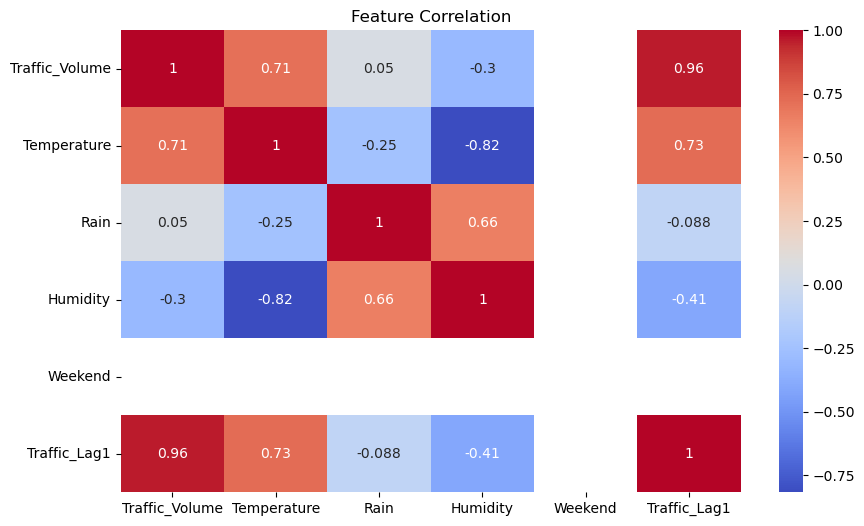

In [18]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

In [19]:
# Standardizing numerical features
scaler = StandardScaler()

df[['Traffic_Volume','Temperature','Humidity']] = scaler.fit_transform(
    df[['Traffic_Volume','Temperature','Humidity']]
)

In [20]:
# Save cleaned dataset
df.to_csv("processed_traffic_dataset.csv", index=False)

# Conclusion

The dataset was cleaned by handling missing values, removing duplicates, and correcting data types. 
Traffic data was aggregated into hourly intervals for each junction. Feature engineering was performed 
to generate time-based variables and lag features. Categorical variables were encoded and numerical 
features were standardized to prepare the dataset for machine learning modeling.